In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = r'C:\Users\malaa\Downloads\KHCC_Dataset_v4_Accurate 2.xlsx'

patients = pd.read_excel(path, sheet_name='Patient Profiles (250)')s
donors   = pd.read_excel(path, sheet_name='Donor Profiles (250)')
matches  = pd.read_excel(path, sheet_name='Match History (Interactions)')

In [5]:
print("Patient nulls:")
print(patients.isnull().sum())
print("\nDonor nulls:")
print(donors.isnull().sum())
print("\nMatch nulls:")
print(matches.isnull().sum())

Patient nulls:
Patient ID                      0
Full Name                       0
Gender                          0
Age                             0
Nationality                     0
Governorate                     0
Marital Status                  0
Num Children                    0
Total Dependents                0
Spouse Works                    0
Father Age                      0
Monthly Income JD               0
Insurance Type                  0
Zakat Eligible                  0
Cancer Type                     0
Cancer Stage                    0
Treatment Type                  0
Est Treatment Cost JD           0
Days on Waitlist                0
Application Date                0
Psychosocial Support Needed     0
Previous Aid Received          28
Need Score 0 to 1               0
Recommended Programs            0
Equipment Needed               46
Urgency Score                   0
Urgency Flag                    0
dtype: int64

Donor nulls:
Donor ID                      0
Full Nam

In [6]:
patients['Previous Aid Received'].fillna('No', inplace=True)
patients['Equipment Needed'].fillna('None', inplace=True)
donors['Gender'].fillna('Unknown', inplace=True)

print("Patient nulls after fix:", patients.isnull().sum().sum())
print("Donor nulls after fix  :", donors.isnull().sum().sum())

Patient nulls after fix: 0
Donor nulls after fix  : 0


C:\Users\malaa\AppData\Local\Temp\ipykernel_20908\2056954249.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  patients['Previous Aid Received'].fillna('No', inplace=True)
C:\Users\malaa\AppData\Local\Temp\ipykernel_20908\2056954249.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [7]:
print("Patient duplicates:", patients.duplicated().sum())
print("Donor duplicates  :", donors.duplicated().sum())
print("Match duplicates  :", matches.duplicated().sum())

Patient duplicates: 0
Donor duplicates  : 0
Match duplicates  : 0


In [8]:
stage_map = {'Stage I': 1, 'Stage II': 2, 'Stage III': 3, 'Stage IV': 4}
patients['CancerStageNum'] = patients['Cancer Stage'].map(stage_map)
patients['GenderNum']      = (patients['Gender'] == 'Female').astype(int)
patients['ZakatNum']       = (patients['Zakat Eligible'] == 'Yes').astype(int)
patients['UrgencyNum']     = (patients['Urgency Flag'] == 'High').astype(int)

print(patients[['CancerStageNum','GenderNum',
                'ZakatNum','UrgencyNum']].head(8))

   CancerStageNum  GenderNum  ZakatNum  UrgencyNum
0               3          1         1           0
1               3          1         1           0
2               4          1         1           0
3               3          1         0           0
4               3          1         0           0
5               2          0         1           0
6               4          0         0           0
7               4          0         1           0


In [6]:
patients['NeedUrgencyScore'] = (
    patients['Need Score 0 to 1'] * 0.6 +
    patients['Urgency Score'] * 0.4
).round(3)

patients['DependencyRatio'] = (
    patients['Total Dependents'] / (patients['Monthly Income JD'] + 1)
).round(3)

patients['HighRiskFlag'] = (
    (patients['CancerStageNum'] >= 3) &
    (patients['Monthly Income JD'] < 300)
).astype(int)

patients['CostIncomeRatio'] = (
    patients['Est Treatment Cost JD'] / (patients['Monthly Income JD'] + 1)
).round(3)

print(patients[['NeedUrgencyScore','DependencyRatio',
                'HighRiskFlag','CostIncomeRatio']].describe())

       NeedUrgencyScore  DependencyRatio  HighRiskFlag  CostIncomeRatio
count        111.000000       111.000000    111.000000       111.000000
mean           0.426342         0.304793      0.342342      1036.198180
std            0.111450         1.056154      0.476645      2916.199458
min            0.170000         0.000000      0.000000         2.914000
25%            0.346000         0.003000      0.000000        15.952000
50%            0.426000         0.007000      0.000000        28.678000
75%            0.513000         0.015500      1.000000        57.677000
max            0.692000         7.000000      1.000000     15000.000000


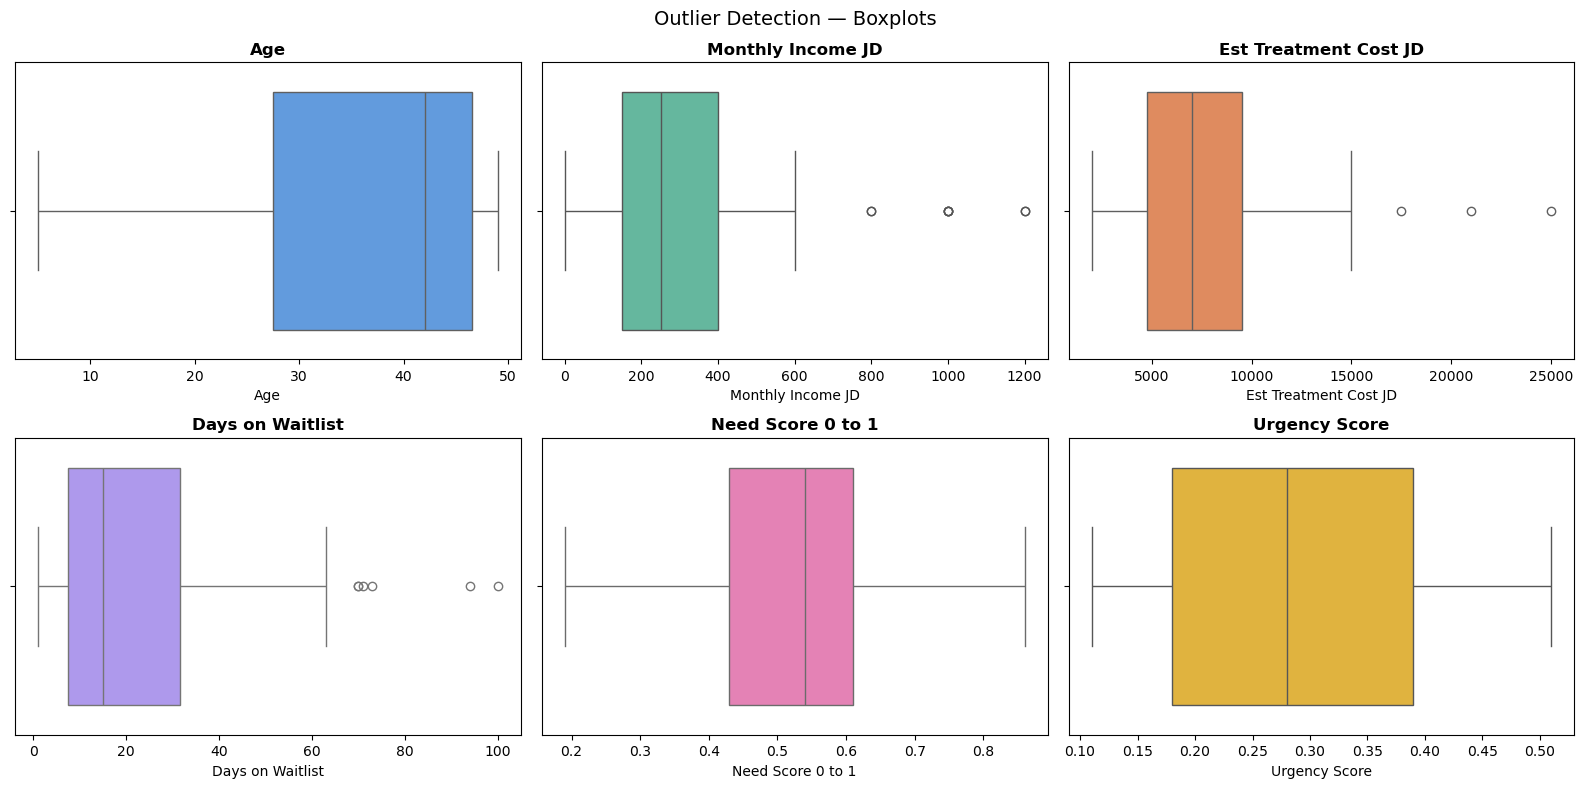

In [7]:
cols = ['Age', 'Monthly Income JD', 'Est Treatment Cost JD',
        'Days on Waitlist', 'Need Score 0 to 1', 'Urgency Score']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
colors = ['#4E9AF1','#57C5A3','#F4844A','#A78BFA','#F472B6','#FBBF24']

for i, col in enumerate(cols):
    sns.boxplot(x=patients[col], ax=axes[i//3][i%3], color=colors[i])
    axes[i//3][i%3].set_title(col, fontweight='bold')

plt.suptitle('Outlier Detection — Boxplots', fontsize=14)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
from sklearn.preprocessing import MinMaxScaler

knn_features = ['Age', 'Monthly Income JD', 'Need Score 0 to 1',
                'Urgency Score', 'CancerStageNum',
                'Total Dependents', 'Days on Waitlist']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(patients[knn_features])

print("Scaled range:")
print(f"  Min = {X_scaled.min():.2f}, Max = {X_scaled.max():.2f}")
print(f"  Shape = {X_scaled.shape}")

Scaled range:
  Min = 0.00, Max = 1.00
  Shape = (111, 7)


In [9]:
patients.to_csv(r'C:\Users\malaa\Downloads\patients_clean.csv', index=False)
donors.to_csv(r'C:\Users\malaa\Downloads\donors_clean.csv', index=False)
matches.to_csv(r'C:\Users\malaa\Downloads\matches_clean.csv', index=False)
print("✓ Saved 3 cleaned CSV files to Downloads folder")

✓ Saved 3 cleaned CSV files to Downloads folder
